## TP de Machine Learning — Naive Bayes & XGBoost
**Nom Complet :** Mohammed NASSIRI

**Utilisateur GitHub :** PunchArm255

---

Ce notebook implémente **2 algorithmes de classification avancés** :
1. **Naive Bayes** — Classification bayésienne gaussienne
2. **XGBoost** — Gradient Boosting avec souches de décision

Chaque algorithme est comparé entre une implémentation **From Scratch** et **Scikit-Learn**.

### IMPORTATION DES BIBLIOTHÈQUES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
%matplotlib inline

### IMPLÉMENTATIONS FROM SCRATCH

In [2]:
class NaiveBayesFromScratch:
    """Naive Bayes Gaussien implémenté manuellement."""
    def __init__(self): self.mean = None; self.var = None; self.priors = None; self.classes = None
    def fit(self, X, y):
        self.classes = np.unique(y); nc = len(self.classes); nf = X.shape[1]
        self.mean = np.zeros((nc, nf)); self.var = np.zeros((nc, nf)); self.priors = np.zeros(nc)
        for i, c in enumerate(self.classes):
            Xc = X[y == c]; self.mean[i] = Xc.mean(0); self.var[i] = Xc.var(0); self.priors[i] = len(Xc)/len(y)
    def predict(self, X):
        preds = []
        for x in X:
            posts = []
            for i, c in enumerate(self.classes):
                prior = np.log(self.priors[i])
                lk = -0.5*np.sum(np.log(2*np.pi*self.var[i]+1e-10) + (x-self.mean[i])**2/(self.var[i]+1e-10))
                posts.append(prior + lk)
            preds.append(self.classes[np.argmax(posts)])
        return np.array(preds)

class XGBoostFromScratch:
    """Gradient Boosting simplifié avec souches de décision."""
    def __init__(self, n_estimators=50, lr=0.1):
        self.n_est = n_estimators; self.lr = lr; self.stumps = []; self.base = 0
    def _sigmoid(self, z): return 1/(1+np.exp(-np.clip(z,-500,500)))
    def fit(self, X, y):
        pos = np.sum(y==1); neg = np.sum(y==0)
        self.base = np.log((pos+1e-10)/(neg+1e-10))
        F = np.full(len(y), self.base, dtype=float)
        for _ in range(self.n_est):
            res = y - self._sigmoid(F); best = (0, 0, 0, 0, float('inf'))
            for f in range(X.shape[1]):
                for t in np.percentile(X[:,f], np.arange(10,100,10)):
                    lm = X[:,f]<=t
                    if np.sum(lm)==0 or np.sum(~lm)==0: continue
                    lv, rv = np.mean(res[lm]), np.mean(res[~lm])
                    loss = np.mean((res - np.where(lm, lv, rv))**2)
                    if loss < best[4]: best = (f, t, lv, rv, loss)
            self.stumps.append(best[:4])
            f,t,lv,rv = best[:4]; F += self.lr * np.where(X[:,f]<=t, lv, rv)
    def predict(self, X):
        F = np.full(len(X), self.base, dtype=float)
        for f,t,lv,rv in self.stumps: F += self.lr * np.where(X[:,f]<=t, lv, rv)
        return (self._sigmoid(F) >= 0.5).astype(int)

### PRÉPARATION DES DONNÉES

In [3]:
df = pd.read_csv('data/medical_costs.csv')
median_cost = np.median(df['cost'].values)
y_class = (df['cost'].values >= median_cost).astype(int)
X_class = df[['age', 'bmi']].values
X_train, X_test, y_train, y_test = train_test_split(X_class, y_class, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
h = 0.5
x_min, x_max = X_class[:,0].min()-2, X_class[:,0].max()+2
y_min, y_max = X_class[:,1].min()-2, X_class[:,1].max()+2
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
grid = np.c_[xx.ravel(), yy.ravel()]
grid_scaled = scaler.transform(grid)
colors = np.where(y_class==1, '#e74c3c', '#3498db')
print(f"Échantillons : {len(df)} | Seuil médiane : {median_cost:.2f}")

Échantillons : 500 | Seuil médiane : 17141.39


### TEST 1 : NAIVE BAYES GAUSSIEN
Le classificateur **Naive Bayes** suppose que les caractéristiques sont **indépendantes** et suivent une **distribution gaussienne**. Malgré cette hypothèse simpliste, il fonctionne bien en pratique.

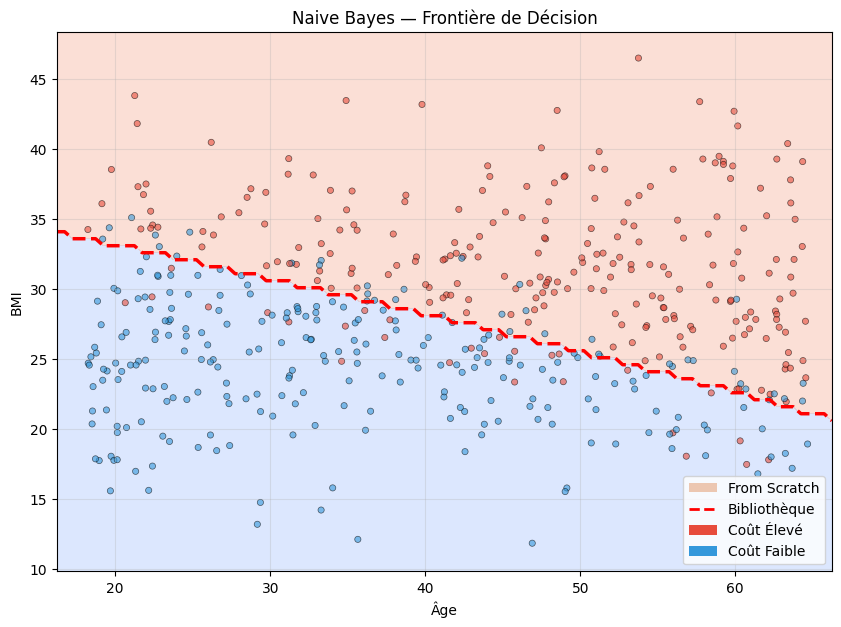

In [4]:
m_scratch = NaiveBayesFromScratch(); m_scratch.fit(X_train_scaled, y_train)
m_sklearn = GaussianNB(); m_sklearn.fit(X_train_scaled, y_train)
Z1 = m_scratch.predict(grid_scaled).reshape(xx.shape)
Z2 = m_sklearn.predict(grid_scaled).reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z1, alpha=0.3, cmap='coolwarm', levels=np.linspace(-0.5,1.5,3))
plt.contour(xx, yy, Z2, colors='red', linestyles='dashed', linewidths=2.5, levels=[0.5])
plt.scatter(X_class[:,0], X_class[:,1], c=colors, edgecolors='black', s=20, alpha=0.6, linewidths=0.5)
plt.title('Naive Bayes — Frontière de Décision')
plt.xlabel('Âge'); plt.ylabel('BMI')
plt.legend(handles=[
    Patch(facecolor='#d35400', alpha=0.3, label='From Scratch'),
    Line2D([0],[0], color='red', linestyle='dashed', linewidth=2, label='Bibliothèque'),
    Patch(facecolor='#e74c3c', label='Coût Élevé'),
    Patch(facecolor='#3498db', label='Coût Faible')])
plt.grid(True, alpha=0.3); plt.show()

### TEST 2 : XGBOOST (Gradient Boosting)
**XGBoost** combine plusieurs **apprenants faibles** (ici des souches de décision) de manière séquentielle. Chaque nouvel apprenant corrige les erreurs du précédent via le **gradient de la fonction de perte**.

Calcul des frontières de décision XGBoost...
Terminé !


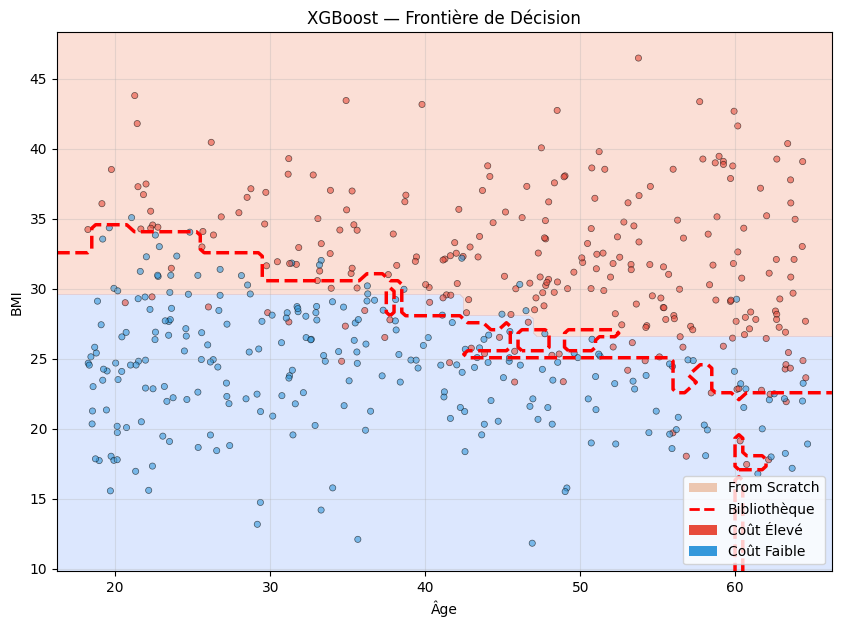

In [5]:
m_scratch = XGBoostFromScratch(n_estimators=50, lr=0.1)
m_scratch.fit(X_train, y_train)
m_sklearn = GradientBoostingClassifier(n_estimators=50, max_depth=3, random_state=42)
m_sklearn.fit(X_train, y_train)
print('Calcul des frontières de décision XGBoost...')
Z1 = m_scratch.predict(grid).reshape(xx.shape)
Z2 = m_sklearn.predict(grid).reshape(xx.shape)
print('Terminé !')

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z1, alpha=0.3, cmap='coolwarm', levels=np.linspace(-0.5,1.5,3))
plt.contour(xx, yy, Z2, colors='red', linestyles='dashed', linewidths=2.5, levels=[0.5])
plt.scatter(X_class[:,0], X_class[:,1], c=colors, edgecolors='black', s=20, alpha=0.6, linewidths=0.5)
plt.title('XGBoost — Frontière de Décision')
plt.xlabel('Âge'); plt.ylabel('BMI')
plt.legend(handles=[
    Patch(facecolor='#d35400', alpha=0.3, label='From Scratch'),
    Line2D([0],[0], color='red', linestyle='dashed', linewidth=2, label='Bibliothèque'),
    Patch(facecolor='#e74c3c', label='Coût Élevé'),
    Patch(facecolor='#3498db', label='Coût Faible')])
plt.grid(True, alpha=0.3); plt.show()